# File Creater for the TOLIMAN Pupil

Install necessary packages

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import jax.numpy as np

import dLux as dl
import dLux.utils as dlu
import dLuxToliman as dlT
import src.OpticsSupport as OpticsSupport
import src.PlottingSupport as PlottingSupport
import src.STLMaker as STLMaker
import math
import scienceplots
import tqdm
import scipy as sp

plt.style.use(["science", "bright", "no-latex"])

cividis = mpl.colormaps["cividis"]
viridis = mpl.colormaps["viridis"]

cividis.set_bad("k", 1.0)
viridis.set_bad("k", 1.0)

## Parameters

In [2]:
# Aperture parameters
ratio = 1  # Ratio to scale the aperture by (e.g. 5 => 5-inch aperture becomes 1-inch aperture)
aperture_npix = 5000  # Number of pixels across the aperture
aperture_diameter = 0.125 / ratio  # Clear aperture diameter (m)
secondary_diameter = 0.032 / ratio  # Secondary mirror diameter (m)
spider_width = 0.002 / ratio  # Spider width (m)
pixel_pitch = 2.74  # Pixel pitch (microns)
plate_scale = 0.15625  # Plate scale (arcsec/micron)

# Observations wavelegths (bandpass of 530-640nm)
wavelengths = np.linspace(530e-9, 640e-9, 3)  # Wavelengths to simulate (m)

# Subtrate parameters
n1 = 1  # Refractive index of free space
n2 = 1.5424  # Refractive index of Zerodur

# Mask
mask_path = "diffractive_pupil.npy"
phase_mask = np.load(mask_path) * np.pi  # Load the mask and convert to phase
original_mask = np.copy(phase_mask)  # Save the original mask for later

# Grating parameters
amplitude = 375e-9  # Amplitude of the grating (m). Peak to peak amplitude of the grating etched in the glass
det_npixels = 4504  # DO NOT TOUCH
pixel_scale = (
    dlu.arcsec2rad(pixel_pitch * plate_scale) * ratio
)  # 0.428 arcsec per pixel
# max_reach = 0.691443  # Max wavelength to diffract to 69.1443% of the diagonal length of the detector

In [3]:
max_reaches = np.linspace(0.05, 0.98, 100)
peak_wavelength = 585e-9
source = dl.PointSource(wavelengths=[530e-9, 585e-9, 640e-9], position=(0, 0))
wf_npixels = aperture_npix  # Number of pixels across the wavefront
peak_wavelength = 585e-9  # Peak wavelength of the bandpass (m)
peaks = []

In [4]:
for max_reach in tqdm.tqdm(max_reaches):
    # Make the mask
    _, raw_mask, X, Y = OpticsSupport.HelperFunctions.make_grating_mask(
        original_mask,
        aperture_npix,
        aperture_diameter,
        secondary_diameter,
        spider_width,
        wavelengths,
        amplitude,
        det_npixels,
        pixel_scale,
        max_reach,
        n1,
        n2,
        out=0.0,
        apply_spiders=False,
        return_raw=True,
    )

    # Create Telescope
    phase_mask = OpticsSupport.HelperFunctions.createPhaseMask(
        raw_mask, peak_wavelength, n1, n2
    )  # Create the phase mask
    mask = dl.Optic(phase=phase_mask)
    optics = dlT.TolimanOpticalSystem(
        wf_npixels=wf_npixels, mask=mask, psf_npixels=det_npixels, oversample=1
    )
    instrument = OpticsSupport.HelperFunctions.createTolimanTelescope(
        optics, source, ratio
    )
    psf = instrument.model()

    # r = psf.shape[0]
    # plt.plot(psf.diagonal())
    # plt.show()
    peaks.append(
        sp.signal.find_peaks(psf.diagonal(), height=0.001)[0].tolist()
    )
    del instrument, optics, psf, mask, phase_mask

  0%|          | 0/100 [00:00<?, ?it/s]

Nyquist Ratio: 38.72676086425781
Grating amplitude (nm): 375.0nm
Grating amplitude (rads): 0.6953845620155334$\pi$ rads
Grating period: 0.001936337910592556m


  1%|          | 1/100 [01:02<1:42:29, 62.12s/it]

Nyquist Ratio: 32.60160827636719
Grating amplitude (nm): 375.0nm
Grating amplitude (rads): 0.6953845620155334$\pi$ rads
Grating period: 0.0016300803981721401m


  2%|▏         | 2/100 [02:02<1:39:18, 60.80s/it]

...

 98%|█████████▊| 98/100 [1:26:23<01:57, 58.52s/it]

Nyquist Ratio: 1.9949917793273926
Grating amplitude (nm): 375.0nm
Grating amplitude (rads): 0.6953845620155334$\pi$ rads
Grating period: 9.974958811653778e-05m


 99%|█████████▉| 99/100 [1:27:21<00:58, 58.27s/it]

Nyquist Ratio: 1.9758687019348145
Grating amplitude (nm): 375.0nm
Grating amplitude (rads): 0.6953845620155334$\pi$ rads
Grating period: 9.879343269858509e-05m


100%|██████████| 100/100 [1:28:14<00:00, 52.95s/it]


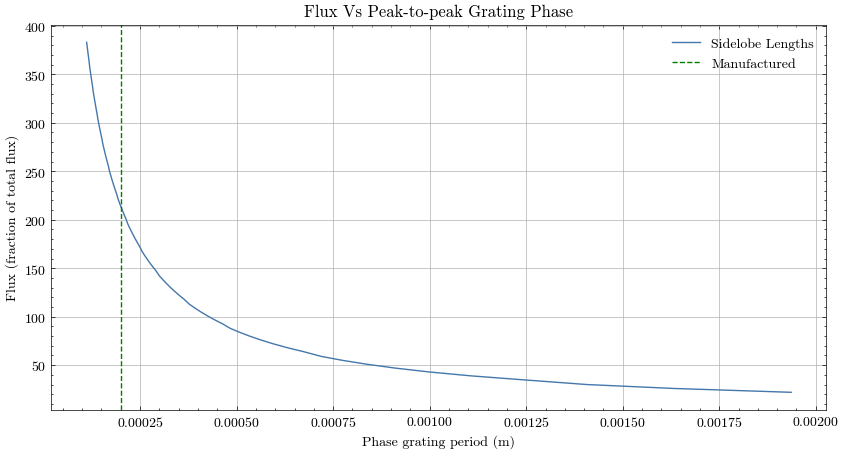

In [11]:
sidelobe_lengths = [peak[2] - peak[0] for peak in peaks[:-12]]
# grating_periods = (
#     max_reaches * 2 * 375e-9 * (n2 - n1) / (585e-9)
# )  # Manufactured sidelobe length
diffraction_angle = max_reaches * pixel_scale * np.sqrt(2) * (det_npixels / 2)
periods = wavelengths.max() / np.sin(diffraction_angle)

plt.figure(figsize=(10, 5))
plt.plot(periods[:-12], sidelobe_lengths, label="Sidelobe Lengths")
plt.axvline(
    200e-6,
    color="green",
    linestyle="--",
    label="Manufactured",
)
plt.xlabel(r"Phase grating period (m)")
plt.ylabel("Flux (fraction of total flux)")
plt.legend()
plt.title("Flux Vs Peak-to-peak Grating Phase")
plt.grid()
plt.show()

In [12]:
with open("imx541/sidelobe_results.txt", "w") as f:
    f.write("Max Reach, Grating Period ($\mu$m), Sidelobe Length (pixels)\n")
    for max, pe, sl in zip(max_reaches, periods, sidelobe_lengths):
        f.write(f"{max:.6e}, {pe:.6f}, {sl:.6f}\n")

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
/var/folders/2l/9nw6bq2n5r3759l7ckh_4mv40000gn/T/ipykernel_23377/2362711660.py:2: SyntaxWarning: invalid escape sequence '\m'
  f.write("Max Reach, Grating Period ($\mu$m), Sidelobe Length (pixels)\n")
